# scMUG latent space exploration and cluster-to-cell-type mapping

This notebook rebuilds the Muraro `AnnData` object from `datasets/muraro.h5`, loads scMUG latent representations and predicted clusters, links those cluster labels to the known `cell_type1` annotation, and produces diagnostic tables and UMAP plots.

Expected relative paths:

- `datasets/muraro.h5`
- `outputs/muraro_latents.joblib`
- `outputs/muraro_pred_label.joblib`

Main outputs:

- `adata.obsm["X_scMUG"]`: flattened scMUG latent representation
- `adata.obs["scMUG_cluster"]`: predicted scMUG cluster label
- `adata.obs["scMUG_cluster_celltype"]`: dominant cell type assigned to each scMUG cluster
- optional saved file: `data/muraro_scMUG_linked.h5ad`


## 1. Imports and configuration


In [1]:
from pathlib import Path
import warnings

import h5py
import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import anndata as ad
import scanpy as sc

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings("default")

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, frameon=False)

DATASET_PATH = Path("datasets/muraro.h5")
LATENTS_PATH = Path("outputs/muraro_latents.joblib")
LABELS_PATH = Path("outputs/muraro_pred_label.joblib")
OUTPUT_H5AD_PATH = Path("data/muraro_scMUG_linked.h5ad")

CELL_TYPE_COL = "cell_type1"
SCMUG_REP_KEY = "X_scMUG"
SCMUG_CLUSTER_COL = "scMUG_cluster"
SCMUG_DOMINANT_CELLTYPE_COL = "scMUG_cluster_celltype"

for path in [DATASET_PATH, LATENTS_PATH, LABELS_PATH]:
    if not path.is_file():
        raise FileNotFoundError(f"Missing required file: {path.resolve()}")

print("All required files found.")


All required files found.


## 2. Helper functions


In [ ]:
def decode_array(arr):
    # Decode HDF5 byte/string arrays into NumPy arrays usable by pandas/AnnData.
    arr = np.asarray(arr)

    if arr.dtype.kind == "S":
        return arr.astype(str)

    if arr.dtype.kind == "O":
        return np.asarray(
            [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in arr],
            dtype=str,
        )

    return arr


def print_h5_structure(h5_path, max_items=120, show_attrs=True):
    # Print a compact HDF5 structure preview.
    if max_items < 1:
        raise ValueError("max_items must be at least 1.")

    with h5py.File(h5_path, "r") as f:
        count = 0

        def visitor(name, obj):
            nonlocal count

            if count >= max_items:
                return True

            depth = name.count("/")
            indent = "  " * depth

            if isinstance(obj, h5py.Dataset):
                print(
                    f"{indent}[DATASET] {name} | shape={obj.shape} | dtype={obj.dtype}"
                )
            else:
                print(f"{indent}[GROUP]   {name}")

            if show_attrs and obj.attrs:
                for attr_name, attr_value in obj.attrs.items():
                    print(f"{indent}  @ {attr_name} = {attr_value}")

            count += 1
            return True if count >= max_items else None

        f.visititems(visitor)

        if count >= max_items:
            print(f"\nDisplay stopped after {max_items} objects.")


## 3. Inspect the HDF5 file

This confirms what is inside the Muraro HDF5 file before rebuilding the sparse expression matrix.


In [3]:
with h5py.File(DATASET_PATH, "r") as f:
    print(f"File: {DATASET_PATH}")
    print("Root objects:")

    for key, obj in f.items():
        obj_type = type(obj).__name__
        shape = getattr(obj, "shape", None)
        dtype = getattr(obj, "dtype", None)
        print(f"- {key}: type={obj_type}, shape={shape}, dtype={dtype}")

print("\nDetailed structure preview:")
print_h5_structure(DATASET_PATH)


File: datasets/muraro.h5
Root objects:
- exprs: type=Group, shape=None, dtype=None
- obs: type=Group, shape=None, dtype=None
- obs_names: type=Dataset, shape=(2122,), dtype=|S9
- uns: type=Group, shape=None, dtype=None
- var: type=Group, shape=None, dtype=None
- var_names: type=Dataset, shape=(19046,), dtype=|S23

Detailed structure preview:
[GROUP]   exprs
  [DATASET] exprs/data | shape=(10905490,) | dtype=float64
  [DATASET] exprs/indices | shape=(10905490,) | dtype=int32
  [DATASET] exprs/indptr | shape=(2123,) | dtype=int32
  [DATASET] exprs/shape | shape=(2,) | dtype=int32
[GROUP]   obs
  [DATASET] obs/batch | shape=(2122,) | dtype=|S2
  [DATASET] obs/cell_ontology_class | shape=(2122,) | dtype=|S25
  [DATASET] obs/cell_ontology_id | shape=(2122,) | dtype=|S11
  [DATASET] obs/cell_type1 | shape=(2122,) | dtype=|S12
  [DATASET] obs/dataset_name | shape=(2122,) | dtype=|S7
  [DATASET] obs/donor | shape=(2122,) | dtype=|S4
  [DATASET] obs/organ | shape=(2122,) | dtype=|S9
  [DATASET]

## 4. Load expression matrix, observation names, and variable names

The expression matrix is stored in CSR sparse format under `exprs`.


In [4]:
with h5py.File(DATASET_PATH, "r") as f:
    exprs = f["exprs"]

    data_h5 = exprs["data"][:]
    indices = exprs["indices"][:]
    indptr = exprs["indptr"][:]
    shape = tuple(int(x) for x in exprs["shape"][:])

    obs_names = decode_array(f["obs_names"][:])
    var_names = decode_array(f["var_names"][:])

assert len(shape) == 2
assert len(data_h5) == len(indices)
assert len(indptr) == shape[0] + 1
assert indptr[-1] == len(data_h5)
assert shape[0] == len(obs_names)
assert shape[1] == len(var_names)

X = sparse.csr_matrix(
    (data_h5, indices, indptr),
    shape=shape,
    dtype=np.float32,
)

X.sum_duplicates()
X.sort_indices()
X.eliminate_zeros()

density = X.nnz / np.prod(X.shape)

print("Sparse shape:", X.shape)
print("X dtype:", X.dtype)
print("X nnz:", X.nnz)
print("X density:", f"{density:.6f}")
print("CSR canonical:", X.has_canonical_format)


Sparse shape: (2122, 19046)
X dtype: float32
X nnz: 10905490
X density: 0.269834
CSR canonical: True


## 5. Load observation metadata

The known biological annotation appears to be `cell_type1`. This notebook uses that as the reference cell-type label.


In [5]:
with h5py.File(DATASET_PATH, "r") as f:
    obs_dict = {key: decode_array(dataset[:]) for key, dataset in f["obs"].items()}

invalid_obs = {
    key: len(values)
    for key, values in obs_dict.items()
    if len(values) != len(obs_names)
}

if invalid_obs:
    raise ValueError(f"Invalid observation-column lengths: {invalid_obs}")

obs = pd.DataFrame(obs_dict, index=pd.Index(obs_names.astype(str), name="cell_id"))

print("obs shape:", obs.shape)
print("duplicated cell IDs:", int(obs.index.duplicated().sum()))
print("obs columns:", obs.columns.tolist())

if CELL_TYPE_COL not in obs.columns:
    raise KeyError(
        f"Expected cell type column {CELL_TYPE_COL!r} was not found. "
        f"Available columns: {obs.columns.tolist()}"
    )

print("\nCell type counts:")
display(obs[CELL_TYPE_COL].value_counts(dropna=False).to_frame("n_cells"))

obs.head()


obs shape: (2122, 9)
duplicated cell IDs: 0
obs columns: ['batch', 'cell_ontology_class', 'cell_ontology_id', 'cell_type1', 'dataset_name', 'donor', 'organ', 'organism', 'platform']

Cell type counts:


,n_cells
cell_type1,
alpha,812
beta,448
ductal,245
acinar,219
delta,193
gamma,101
mesenchymal,80
endothelial,21
epsilon,3


,batch,cell_ontology_class,cell_ontology_id,cell_type1,dataset_name,donor,organ,organism,platform
cell_id,,,,,,,,,
D28.1_1,1,pancreatic A cell,CL:0000171,alpha,Muraro,D28,Pancreas,Homo sapiens,CEL-Seq2
D28.1_13,1,pancreatic ductal cell,CL:0002079,ductal,Muraro,D28,Pancreas,Homo sapiens,CEL-Seq2
D28.1_15,1,pancreatic A cell,CL:0000171,alpha,Muraro,D28,Pancreas,Homo sapiens,CEL-Seq2
D28.1_17,1,pancreatic A cell,CL:0000171,alpha,Muraro,D28,Pancreas,Homo sapiens,CEL-Seq2
D28.1_2,1,endothelial cell,CL:0000115,endothelial,Muraro,D28,Pancreas,Homo sapiens,CEL-Seq2


## 6. Load variable metadata and construct `AnnData`


In [6]:
with h5py.File(DATASET_PATH, "r") as f:
    var_keys = list(f["var"].keys()) if "var" in f else []

print("var keys:", var_keys)

var = pd.DataFrame(index=pd.Index(var_names.astype(str), name="gene_id"))
var["original_gene_id"] = var.index.astype(str)

print("var shape:", var.shape)
print("duplicated gene IDs:", int(var.index.duplicated().sum()))
print("empty gene IDs:", int(np.sum(var.index.astype(str).str.len() == 0)))

adata = ad.AnnData(X=X, obs=obs.copy(), var=var.copy())

n_duplicated_genes = int(adata.var_names.duplicated().sum())
if n_duplicated_genes > 0:
    print(
        f"Warning: {n_duplicated_genes} duplicated gene IDs detected; "
        "making AnnData var_names unique."
    )
    adata.var_names_make_unique()

with h5py.File(DATASET_PATH, "r") as f:
    if "uns" in f:
        for key, dataset in f["uns"].items():
            adata.uns[key] = decode_array(dataset[:])

assert adata.n_obs == len(obs_names)
assert adata.n_vars == len(var_names)
assert adata.obs_names.is_unique
assert adata.var_names.is_unique
assert sparse.isspmatrix_csr(adata.X)
assert np.isfinite(adata.X.data).all()

print(adata)
print("obs columns:", adata.obs.columns.tolist())
print("uns keys:", list(adata.uns.keys()))


var keys: []
var shape: (19046, 1)
duplicated gene IDs: 0
empty gene IDs: 0
AnnData object with n_obs × n_vars = 2122 × 19046
    obs: 'batch', 'cell_ontology_class', 'cell_ontology_id', 'cell_type1', 'dataset_name', 'donor', 'organ', 'organism', 'platform'
    var: 'original_gene_id'
    uns: 'expressed_genes', 'scmap_genes', 'seurat_genes'
obs columns: ['batch', 'cell_ontology_class', 'cell_ontology_id', 'cell_type1', 'dataset_name', 'donor', 'organ', 'organism', 'platform']
uns keys: ['expressed_genes', 'scmap_genes', 'seurat_genes']


## 7. Load scMUG latents and predicted clusters

The saved objects may contain values for multiple training epochs or checkpoints. The notebook uses the final saved state by taking `[-1]`.


In [7]:
latents = np.asarray(joblib.load(LATENTS_PATH))
pred_labels = np.asarray(joblib.load(LABELS_PATH))

print("Latents raw shape:", latents.shape)
print("Predicted labels raw shape:", pred_labels.shape)

latent_last = latents[-1]
labels_final = pred_labels[-1]

latent_last = np.asarray(latent_last)
labels_final = np.asarray(labels_final).reshape(-1)

print("Final latent shape:", latent_last.shape)
print("Final labels shape:", labels_final.shape)
print("Unique scMUG labels:", np.unique(labels_final))

if latent_last.shape[0] != labels_final.shape[0]:
    raise ValueError(
        f"Latent cells ({latent_last.shape[0]}) and label cells ({labels_final.shape[0]}) do not match."
    )

if latent_last.shape[0] != adata.n_obs:
    raise ValueError(
        f"Latent cells ({latent_last.shape[0]}) and AnnData cells ({adata.n_obs}) do not match. "
        "Check whether latents were generated from the same dataset/subset."
    )

# If the latent is cells × views × dimensions, flatten it to cells × features.
# If already cells × features, this leaves it as a 2D matrix.
latent_matrix = latent_last.reshape(latent_last.shape[0], -1).astype(np.float32)

print("Flattened latent matrix shape:", latent_matrix.shape)


Latents raw shape: (10, 2122, 5, 32)
Predicted labels raw shape: (270, 2122)
Final latent shape: (2122, 5, 32)
Final labels shape: (2122,)
Unique scMUG labels: [0 1 2 3 4 5 6]
Flattened latent matrix shape: (2122, 160)


## 8. Attach latents and clusters to `AnnData`

Important: this assumes that the rows of `latent_matrix` and `labels_final` are in the same cell order as `adata.obs_names`. The dimensions match, but ordering should still be assessed biologically using the diagnostics below.


In [8]:
adata.obsm[SCMUG_REP_KEY] = latent_matrix
adata.obs[SCMUG_CLUSTER_COL] = pd.Categorical(labels_final.astype(str))

assert adata.obsm[SCMUG_REP_KEY].shape[0] == adata.n_obs
assert adata.obs[SCMUG_CLUSTER_COL].shape[0] == adata.n_obs

print(adata)
print("obsm keys:", list(adata.obsm.keys()))
print("scMUG cluster counts:")
display(adata.obs[SCMUG_CLUSTER_COL].value_counts().sort_index().to_frame("n_cells"))


AnnData object with n_obs × n_vars = 2122 × 19046
    obs: 'batch', 'cell_ontology_class', 'cell_ontology_id', 'cell_type1', 'dataset_name', 'donor', 'organ', 'organism', 'platform', 'scMUG_cluster'
    var: 'original_gene_id'
    uns: 'expressed_genes', 'scmap_genes', 'seurat_genes'
    obsm: 'X_scMUG'
obsm keys: ['X_scMUG']
scMUG cluster counts:


,n_cells
scMUG_cluster,
0,232
1,285
2,427
3,145
4,221
5,499
6,313


## 9. Link scMUG clusters to known cell types

This section creates a cluster-by-cell-type count table, a row-normalized enrichment table, and a dominant-cell-type assignment for each scMUG cluster.


In [ ]:
cluster_celltype_counts = pd.crosstab(
    adata.obs[SCMUG_CLUSTER_COL],
    adata.obs[CELL_TYPE_COL],
)

cluster_celltype_fraction = pd.crosstab(
    adata.obs[SCMUG_CLUSTER_COL],
    adata.obs[CELL_TYPE_COL],
    normalize="index",
)

cluster_to_celltype = cluster_celltype_counts.idxmax(axis=1)

cluster_summary = pd.DataFrame(
    {
        "dominant_cell_type": cluster_celltype_counts.idxmax(axis=1),
        "dominant_count": cluster_celltype_counts.max(axis=1),
        "cluster_size": cluster_celltype_counts.sum(axis=1),
    }
)
cluster_summary["purity"] = (
    cluster_summary["dominant_count"] / cluster_summary["cluster_size"]
)
cluster_summary = cluster_summary.sort_values("purity", ascending=False)

adata.obs[SCMUG_DOMINANT_CELLTYPE_COL] = (
    adata.obs[SCMUG_CLUSTER_COL].map(cluster_to_celltype).astype("category")
)

print("Cluster summary:")
display(cluster_summary)

print("Cluster × cell_type counts:")
display(cluster_celltype_counts)

print("Cluster × cell_type row fractions:")
display(cluster_celltype_fraction.round(3))


Cluster summary:


,dominant_cell_type,dominant_count,cluster_size,purity
scMUG_cluster,,,,
5,alpha,498,499,0.997996
1,alpha,284,285,0.996491
2,beta,418,427,0.978923
0,acinar,218,232,0.939655
4,delta,190,221,0.859729
6,ductal,218,313,0.696486
3,gamma,99,145,0.682759


Cluster × cell_type counts:


cell_type1,acinar,alpha,beta,delta,ductal,endothelial,epsilon,gamma,mesenchymal
scMUG_cluster,,,,,,,,,
0,218,1,3,0,8,0,0,2,0
1,0,284,1,0,0,0,0,0,0
2,0,2,418,3,4,0,0,0,0
3,0,0,8,0,15,20,3,99,0
4,0,21,10,190,0,0,0,0,0
5,0,498,1,0,0,0,0,0,0
6,1,6,7,0,218,1,0,0,80


Cluster × cell_type row fractions:


cell_type1,acinar,alpha,beta,delta,ductal,endothelial,epsilon,gamma,mesenchymal
scMUG_cluster,,,,,,,,,
0,0.940,0.004,0.013,0.000,0.034,0.000,0.000,0.009,0.000
1,0.000,0.996,0.004,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.005,0.979,0.007,0.009,0.000,0.000,0.000,0.000
3,0.000,0.000,0.055,0.000,0.103,0.138,0.021,0.683,0.000
4,0.000,0.095,0.045,0.860,0.000,0.000,0.000,0.000,0.000
5,0.000,0.998,0.002,0.000,0.000,0.000,0.000,0.000,0.000
6,0.003,0.019,0.022,0.000,0.696,0.003,0.000,0.000,0.256


## 10. Quantify cluster agreement with cell types

ARI and NMI compare the unsupervised scMUG clusters to the known `cell_type1` labels.

- ARI near 1: strong agreement.
- ARI near 0: agreement close to random expectation.
- NMI near 1: high shared information between clusters and cell types.


In [ ]:
true_cell_types = adata.obs[CELL_TYPE_COL].astype(str)
pred_clusters = adata.obs[SCMUG_CLUSTER_COL].astype(str)

ari = adjusted_rand_score(true_cell_types, pred_clusters)
nmi = normalized_mutual_info_score(true_cell_types, pred_clusters)

metrics = pd.DataFrame({"metric": ["ARI", "NMI"], "value": [ari, nmi]})

metrics


,metric,value
0,ARI,0.681633
1,NMI,0.789087


## 11. Build nearest-neighbor graph and UMAP from scMUG latents


In [11]:
sc.pp.neighbors(adata, use_rep=SCMUG_REP_KEY, key_added="scMUG_neighbors")
sc.tl.umap(adata, neighbors_key="scMUG_neighbors")

print("UMAP coordinates:", adata.obsm["X_umap"].shape)


computing neighbors


/Users/399082/Documents/01_repositories/04_scMUG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:03)
computing UMAP
    finished (0:00:01)
UMAP coordinates: (2122, 2)


## 12. Plot UMAP colored by cluster and cell type


/Users/399082/Documents/01_repositories/04_scMUG/.venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:184: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  cmap.set_bad(na_color)


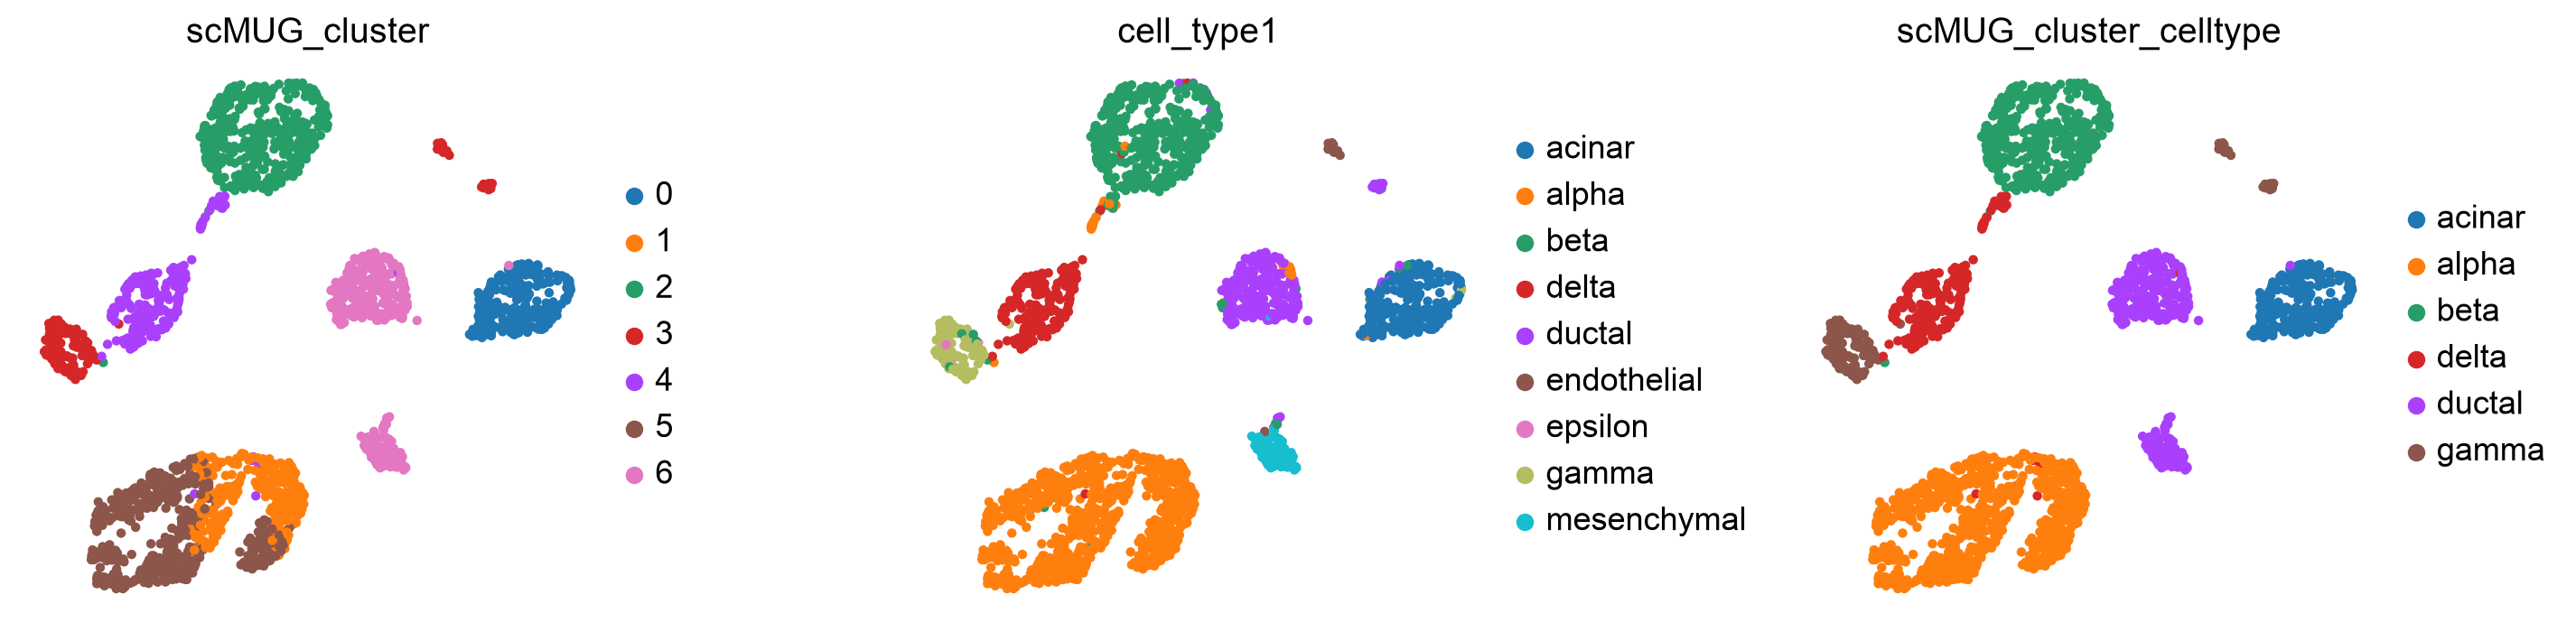

In [ ]:
plt.rcParams.update(
    {
        # Fonds clairs
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        # Écritures noires
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        # Bordures / axes
        "axes.edgecolor": "black",
        # Légendes
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
    }
)

sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)

sc.pl.umap(
    adata,
    color=[SCMUG_CLUSTER_COL, CELL_TYPE_COL, SCMUG_DOMINANT_CELLTYPE_COL],
    wspace=0.4,
    legend_loc="right margin",
)


## 13. Plot cluster-cell-type heatmaps


In [13]:
# Display the two crosstab tables before plotting.
# The next cell creates the main cluster-composition heatmap.

print("Cluster × cell_type counts:")
display(cluster_celltype_counts)

print("Cluster × cell_type row fractions:")
display(cluster_celltype_fraction.round(3))


Cluster × cell_type counts:


cell_type1,acinar,alpha,beta,delta,ductal,endothelial,epsilon,gamma,mesenchymal
scMUG_cluster,,,,,,,,,
0,218,1,3,0,8,0,0,2,0
1,0,284,1,0,0,0,0,0,0
2,0,2,418,3,4,0,0,0,0
3,0,0,8,0,15,20,3,99,0
4,0,21,10,190,0,0,0,0,0
5,0,498,1,0,0,0,0,0,0
6,1,6,7,0,218,1,0,0,80


Cluster × cell_type row fractions:


cell_type1,acinar,alpha,beta,delta,ductal,endothelial,epsilon,gamma,mesenchymal
scMUG_cluster,,,,,,,,,
0,0.940,0.004,0.013,0.000,0.034,0.000,0.000,0.009,0.000
1,0.000,0.996,0.004,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.005,0.979,0.007,0.009,0.000,0.000,0.000,0.000
3,0.000,0.000,0.055,0.000,0.103,0.138,0.021,0.683,0.000
4,0.000,0.095,0.045,0.860,0.000,0.000,0.000,0.000,0.000
5,0.000,0.998,0.002,0.000,0.000,0.000,0.000,0.000,0.000
6,0.003,0.019,0.022,0.000,0.696,0.003,0.000,0.000,0.256


The previous Scanpy matrixplot is not always the most useful for a crosstab, so this pandas-based heatmap uses the row-normalized cluster composition table directly.


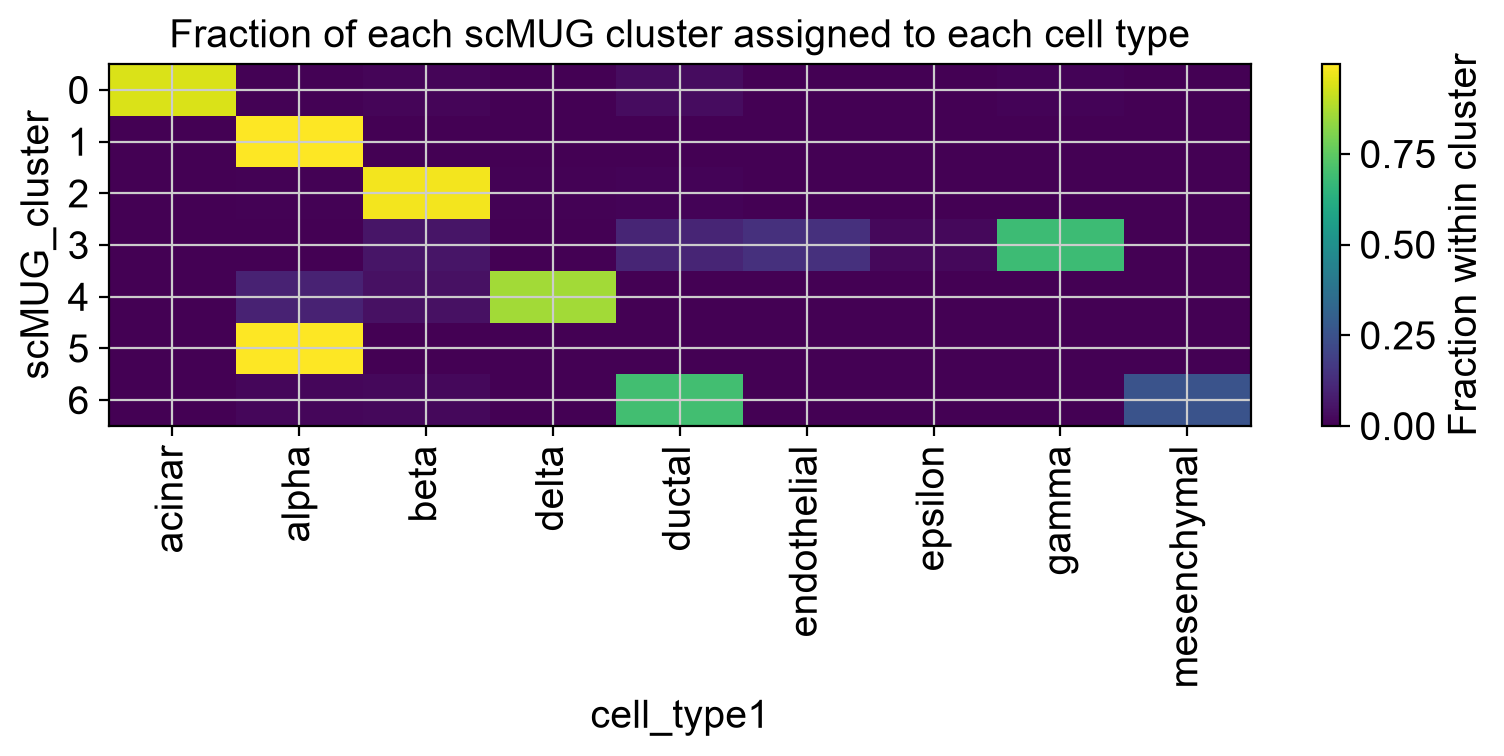

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(
        max(8, 0.55 * cluster_celltype_fraction.shape[1]),
        max(4, 0.35 * cluster_celltype_fraction.shape[0]),
    )
)
im = ax.imshow(cluster_celltype_fraction.values, aspect="auto")

ax.set_xticks(np.arange(cluster_celltype_fraction.shape[1]))
ax.set_xticklabels(cluster_celltype_fraction.columns, rotation=90)
ax.set_yticks(np.arange(cluster_celltype_fraction.shape[0]))
ax.set_yticklabels(cluster_celltype_fraction.index)
ax.set_xlabel(CELL_TYPE_COL)
ax.set_ylabel(SCMUG_CLUSTER_COL)
ax.set_title("Fraction of each scMUG cluster assigned to each cell type")
fig.colorbar(im, ax=ax, label="Fraction within cluster")
plt.tight_layout()
plt.show()


## 14. Sanity checks for possible cell-order mismatch

Matching dimensions only proves the same number of cells, not identical order. If clusters are biologically meaningful, each cluster should usually be enriched for a small number of known cell types. A random-looking crosstab suggests the latent rows may not align with `adata.obs_names`.


In [15]:
print("Minimum cluster purity:", cluster_summary["purity"].min())
print("Median cluster purity:", cluster_summary["purity"].median())
print("Mean cluster purity:", cluster_summary["purity"].mean())

low_purity_clusters = cluster_summary.query("purity < 0.5")

if len(low_purity_clusters) > 0:
    print("\nClusters with purity < 0.5. Inspect these carefully:")
    display(low_purity_clusters)
else:
    print("\nNo clusters with purity < 0.5.")


Minimum cluster purity: 0.6827586206896552
Median cluster purity: 0.9396551724137931
Mean cluster purity: 0.8788625513679644

No clusters with purity < 0.5.


## 15. Save the linked object and summary tables


In [ ]:
OUTPUT_H5AD_PATH.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(OUTPUT_H5AD_PATH, compression="gzip")

summary_dir = OUTPUT_H5AD_PATH.parent
cluster_summary.to_csv(summary_dir / "muraro_scMUG_cluster_summary.csv")
cluster_celltype_counts.to_csv(summary_dir / "muraro_scMUG_cluster_celltype_counts.csv")
cluster_celltype_fraction.to_csv(
    summary_dir / "muraro_scMUG_cluster_celltype_fraction.csv"
)
metrics.to_csv(summary_dir / "muraro_scMUG_cluster_metrics.csv", index=False)

print(f"Saved AnnData to: {OUTPUT_H5AD_PATH}")
print(f"Saved summary tables to: {summary_dir.resolve()}")


Saved AnnData to: data/muraro_scMUG_linked.h5ad
Saved summary tables to: /Users/399082/Documents/01_repositories/04_scMUG/data


## 16. Optional: inspect the final object


In [17]:
print(adata)
print("\nobs columns:", adata.obs.columns.tolist())
print("obsm keys:", list(adata.obsm.keys()))
print("obsp keys:", list(adata.obsp.keys()))
print("uns keys:", list(adata.uns.keys()))
print("layers keys:", list(adata.layers.keys()))

adata.obs[[CELL_TYPE_COL, SCMUG_CLUSTER_COL, SCMUG_DOMINANT_CELLTYPE_COL]].head()


AnnData object with n_obs × n_vars = 2122 × 19046
    obs: 'batch', 'cell_ontology_class', 'cell_ontology_id', 'cell_type1', 'dataset_name', 'donor', 'organ', 'organism', 'platform', 'scMUG_cluster', 'scMUG_cluster_celltype'
    var: 'original_gene_id'
    uns: 'expressed_genes', 'scmap_genes', 'seurat_genes', 'scMUG_neighbors', 'umap', 'scMUG_cluster_colors', 'cell_type1_colors', 'scMUG_cluster_celltype_colors'
    obsm: 'X_scMUG', 'X_umap'
    obsp: 'scMUG_neighbors_distances', 'scMUG_neighbors_connectivities'

obs columns: ['batch', 'cell_ontology_class', 'cell_ontology_id', 'cell_type1', 'dataset_name', 'donor', 'organ', 'organism', 'platform', 'scMUG_cluster', 'scMUG_cluster_celltype']
obsm keys: ['X_scMUG', 'X_umap']
obsp keys: ['scMUG_neighbors_distances', 'scMUG_neighbors_connectivities']
uns keys: ['expressed_genes', 'scmap_genes', 'seurat_genes', 'scMUG_neighbors', 'umap', 'scMUG_cluster_colors', 'cell_type1_colors', 'scMUG_cluster_celltype_colors']
layers keys: []


,cell_type1,scMUG_cluster,scMUG_cluster_celltype
cell_id,,,
D28.1_1,alpha,1,alpha
D28.1_13,ductal,6,ductal
D28.1_15,alpha,1,alpha
D28.1_17,alpha,5,alpha
D28.1_2,endothelial,3,gamma
